# Compute metrics

F1, recall, precision, mean IoU, mean Dice, PQ

Save metrics as:

results/experiment_metrics.csv


In [ ]:
1+1

2

In [1]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy
import skimage
import scipy
import basicpy
from tqdm import tqdm

import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')

from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp

%load_ext autoreload
%autoreload 2

In [2]:
import shutil

In [5]:
# model = '*ablation_dataset_*'
# embed_base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained')
# embed_base_out = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained_backup')

# for i, file in tqdm(enumerate(embed_base.glob(f'{model}/*'))):

#     new_file = embed_base_out / file.parent.parent.parent.parent.name / file.parent.parent.parent.name / file.parent.parent.name / file.parent.name / file.name

#     if new_file.exists():
#         continue
#     new_file.parent.mkdir(exist_ok=True, parents=True)
#     shutil.copy(file, new_file)
#     print(file)
#     print(new_file)
#     # if i > 0:
#     #     break

In [ ]:
# model = 'MicroSAM_*'
# embed_base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_embeddings2')
# embed_base_out = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_embeddings')

# for i, file in tqdm(enumerate(embed_base.glob(f'{model}/train/*/*/*'))):

#     new_file = embed_base_out / file.parent.parent.parent.parent.name / file.parent.parent.parent.name / file.parent.parent.name / file.parent.name / file.name

#     if new_file.exists():
#         continue
#     new_file.parent.mkdir(exist_ok=True, parents=True)
#     shutil.copy(file, new_file)
#     # print(file)
#     # print(new_file)

1128it [01:16, 14.75it/s]


In [32]:
embed_base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_embeddings2')
print('# patches in NeurIPS train:', len(list(embed_base.glob(f'MicroSAM_huge/train/NeurIPSCellSeg_train/*/*.npy'))))

# patches in NeurIPS train: 10940


In [4]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')
# organoid_sam = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


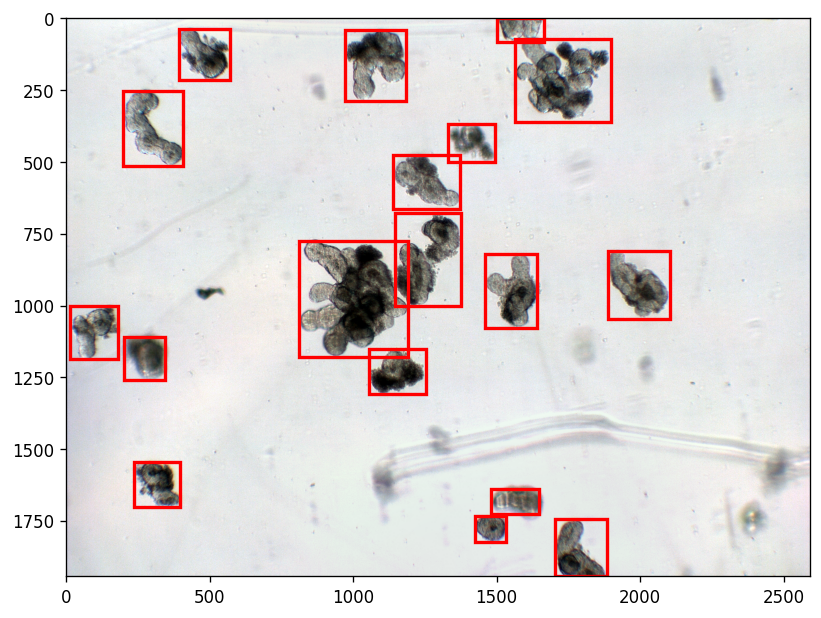

In [5]:
ds = dl.OrganoID(split='test_only_mouse')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

In [37]:
# def convert_mask_to_binary(mask):
#     masks = []
#     for j in sorted(np.unique(mask).astype(int).tolist()):
#         if j == 0:  # background
#             continue
#         # print('j', j)
#         masks.append((mask == j).reshape((-1, mask.shape[0], mask.shape[1])))
#     if len(masks) == 0:
#         return np.array([], dtype=bool).reshape((-1, mask.shape[0], mask.shape[1]))
#     else:
#         return np.stack(masks, axis=0).reshape((-1, mask.shape[0], mask.shape[1]))

# def get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID):
#     box_folder = organoid_sam / 'patch_bbox_gt' / split / ds_name / f'im_{im_ID}'
#     img_folder = organoid_sam / 'patch_images' / split / ds_name / f'im_{im_ID}'
#     mask_folder = organoid_sam / 'patch_seg_gt' / split / ds_name / f'im_{im_ID}'
#     assert box_folder.exists(), box_folder
#     assert img_folder.exists(), img_folder
#     assert mask_folder.exists(), mask_folder

#     offsets = np.load(box_folder / 'offsets.npy')

#     pred_boxes = []
#     pred_scores = []
#     pred_masks = []
#     for patch_number, offset_y, offset_x in offsets:
#         patch_img = cv2.imread(str(img_folder / f'patch_{patch_number}.png'))
#         H, W = patch_img.shape[:2]
#         pred_boxes_patch = np.load(box_folder / f'patch_{patch_number}.npy')
#         pred_boxes_patch = cxcywh_to_xyxy(pred_boxes_patch) * max(H, W) + np.array([[offset_y, offset_x, offset_y, offset_x]])
#         pred_boxes.append(pred_boxes_patch)

#         pred_scores.append(np.random.uniform(0, 1, pred_boxes_patch.shape[0]) + 1)

#         pred_masks_patch = np.load(mask_folder / f'patch_{patch_number}.npy')
#         labels = np.zeros((im.shape[0], im.shape[1]), dtype=pred_masks_patch.dtype)
#         labels[offset_y:offset_y+pred_masks_patch.shape[0], offset_x:offset_x+pred_masks_patch.shape[1]] = pred_masks_patch
#         # for i in sorted(np.unique(labels).astype(int).tolist()):
#         #     if i == 0:  # background
#         #         continue
#         #     mask = labels == i
#         #     pred_masks.append(mask)
#         pred_masks.append(convert_mask_to_binary(labels))

#     pred_boxes = np.concatenate(pred_boxes, axis=0)
#     pred_scores = np.concatenate(pred_scores, axis=0)
#     pred_masks = np.concatenate(pred_masks, axis=0)
#     # pred_masks = np.stack(pred_masks, axis=0)

#     return offsets, pred_boxes, pred_scores, pred_masks


# # /ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM_large/test/OrganoID_test/DetectionHead_SAM_large_OrganoID_train_default_best
# def get_predictions(split, ds_name, pred_folder, im, im_ID):
#     box_folder = organoid_sam / 'patch_bbox_gt' / split / ds_name / f'im_{im_ID}'
#     img_folder = organoid_sam / 'patch_images' / split / ds_name / f'im_{im_ID}'
#     assert box_folder.exists(), box_folder
#     assert img_folder.exists(), img_folder

#     offsets = np.load(box_folder / 'offsets.npy')

#     pred_boxes = []
#     pred_scores = []
#     pred_masks = []
#     for patch_number, offset_y, offset_x in offsets:
#         patch_img = cv2.imread(str(img_folder / f'patch_{patch_number}.png'))
#         H, W = patch_img.shape[:2]


#         pred_boxes_patch = np.load(pred_folder / f'im_{im_ID}' / f'pred_bbs_patch_{patch_number}.npy')
#         # print('pred_boxes_patch.shape', pred_boxes_patch.shape)
#         pred_boxes_patch = cxcywh_to_xyxy(pred_boxes_patch) * max(H, W) + np.array([[offset_y, offset_x, offset_y, offset_x]])
#         pred_boxes.append(pred_boxes_patch)

#         pred_scores_patch = np.load(pred_folder / f'im_{im_ID}' / f'pred_score_patch_{patch_number}.npy')
#         # print('pred_scores_patch.shape', pred_scores_patch.shape)
#         pred_scores.append(pred_scores_patch)

#         pred_masks_patch = np.load(pred_folder / f'im_{im_ID}' / f'pred_mask_patch_{patch_number}.npy')
#         # print('pred_masks_patch.shape', pred_masks_patch.shape)
#         pred_masks_patch = pred_masks_patch.squeeze(1)

#         labels = np.zeros((pred_masks_patch.shape[0], im.shape[0], im.shape[1]), dtype=pred_masks_patch.dtype)
#         labels[:, offset_y:offset_y+pred_masks_patch.shape[1], offset_x:offset_x+pred_masks_patch.shape[2]] = pred_masks_patch
        
#         pred_masks.append(labels)
#         # pred_masks.append(convert_mask_to_binary(labels))

#     pred_boxes = np.concatenate(pred_boxes, axis=0)
#     pred_scores = np.concatenate(pred_scores, axis=0)
#     pred_masks = np.concatenate(pred_masks, axis=0)

#     return pred_boxes, pred_scores, pred_masks

In [38]:
# offsets, pred_boxes, pred_scores, pred_masks = get_pseudo_predictions('test', f'{str(ds)}_{ds.split}', im, mask, boxes, im_path, im_ID)

In [39]:
split = 'test'
pred_folder = Path(f'/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM_large/{split}/{str(ds)}_{ds.split}/DetectionHead_SAM_large_OrganoID_train_default_best')
pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, f'{str(ds)}_{ds.split}', pred_folder, im, im_ID)

In [40]:
pred_boxes

array([[ 400.02017212, 1365.9901123 ,  471.49371338, 1411.96655273],
       [1019.33654785,  105.85324097, 1087.52575684,  167.37071228],
       [ 805.12640381,  751.74554443, 1303.7869873 , 1310.40942383],
       ...,
       [ 878.90988159, 2571.97192383,  953.17672729, 2589.37792969],
       [1738.25195312, 1418.42080688, 1806.39294434, 1499.68292236],
       [1197.42163086, 2002.17260742, 1249.69018555, 2040.61273193]])

In [41]:
pred_masks.shape

(400, 1944, 2592)

In [42]:
(pred_masks.sum(axis=(1, 2)) < 100).sum()

0

In [19]:
# pred_masks = pred_masks[::-1]

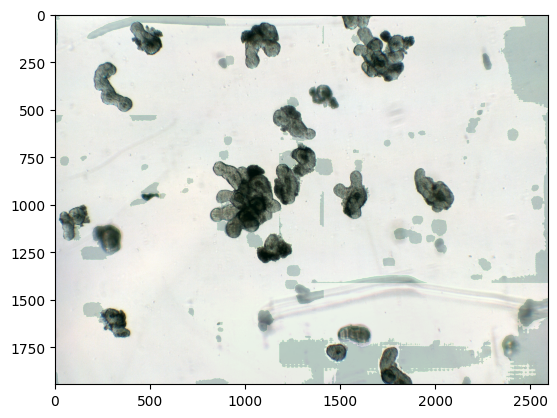

In [44]:
plt.imshow(im)
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255, alpha=0.2, cmap='YlGn')

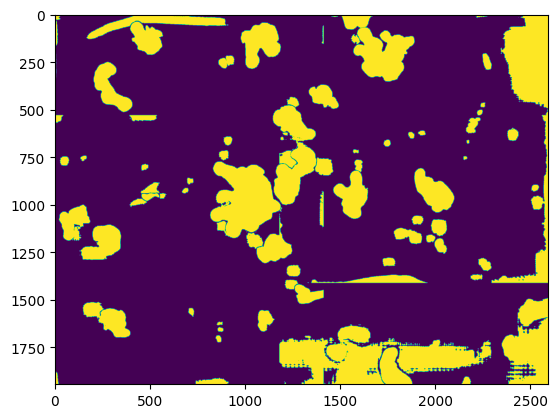

In [45]:
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255)

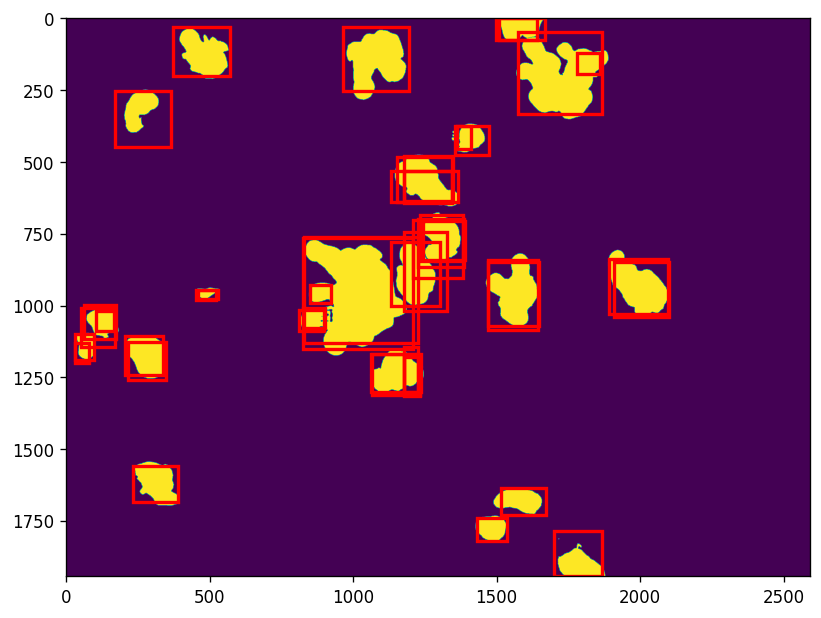

In [46]:
plot_boxes(np.any(pred_masks[pred_scores > 0.9], axis=0).astype(int) * 255, pred_boxes[pred_scores > 0.9], format='yxyx_px')
# plt.imshow(im)

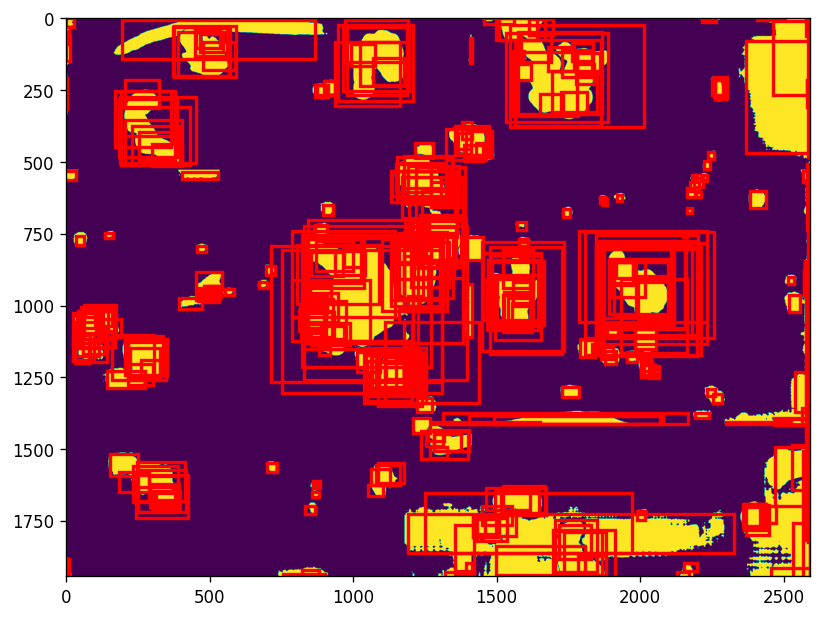

In [47]:
plot_boxes(np.any(pred_masks, axis=0).astype(int) * 255, pred_boxes, format='yxyx_px')

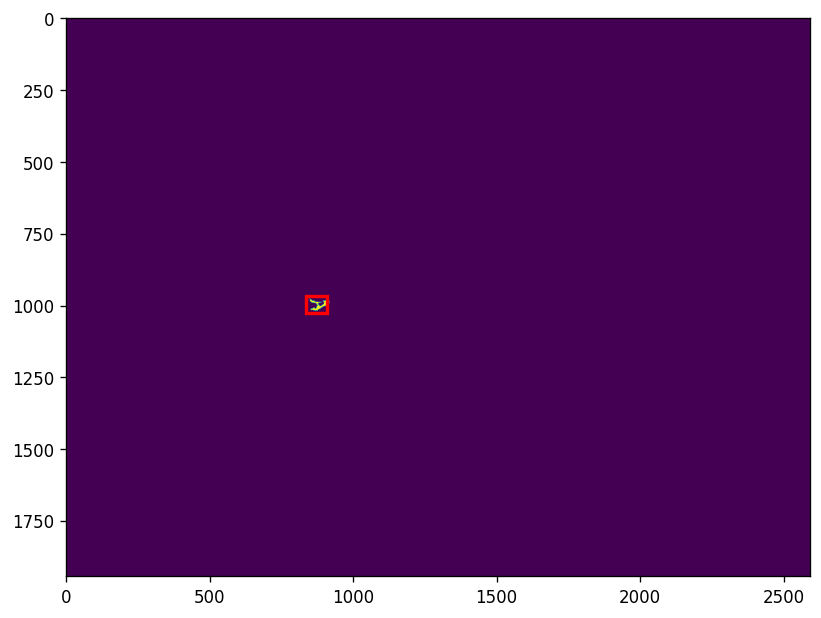

In [48]:
i = 135
plot_boxes(pred_masks[i], pred_boxes[i:i+1], format='yxyx_px')

### Define necessary functions here

In [49]:
# import os
# from PIL import Image
# import numpy as np
# import cv2
# from copy import deepcopy
# from typing import Tuple


# # NMS
# def iou_box_array(box, boxes):

#     box = np.array(box).astype(float)
#     boxes = np.array(boxes).astype(float)

#     assert boxes.ndim==2, boxes.shape
#     assert boxes.shape[1]==4, boxes.shape
#     x_left = np.maximum(box[0], boxes[:, 0])
#     x_right = np.minimum(box[2], boxes[:, 2])
#     y_left = np.maximum(box[1], boxes[:, 1])
#     y_right = np.minimum(box[3], boxes[:, 3])

#     intersection = np.maximum(x_right - x_left, 0) * np.maximum(y_right - y_left, 0)

#     area = (box[2] - box[0]) * (box[3] - box[1]) + (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

#     assert np.all(area > 1), area
#     # print(box, boxes)
#     # print('np.minimum(box[2], boxes[:, 2])', np.minimum(box[2], boxes[:, 2]))
#     # print('intersection', intersection)
#     # print('area', area)
#     _iou = np.where(area - intersection > 0, intersection / (area - intersection), 0.0)
#     assert np.all(_iou >= 0), _iou
#     assert np.all(_iou <= 1), _iou
#     return _iou


# # def nms(boxes, scores, embeddings, thres = 0.9):
# #     boxes = np.array(boxes)
# #     scores = np.array(scores)
# #     embeddings = np.array(embeddings)
    
# #     sorted_ind = np.argsort(scores)[::-1]
# #     boxes_sorted = boxes[sorted_ind]
# #     scores_sorted = scores[sorted_ind]
# #     embeddings_sorted = embeddings[sorted_ind]

# #     out_boxes = []
# #     out_scores = []
# #     out_embeddings = []
# #     # ref_box, ref_score, ref_embed = boxes_sorted[0], scores_sorted[0], embeddings_sorted[0]
# #     remaining_boxes, remaining_scores, remaining_embeds = boxes_sorted, scores_sorted, embeddings_sorted
# #     while len(remaining_boxes) > 0:
# #         ref_box, ref_score, ref_embed = remaining_boxes[0], remaining_scores[0], remaining_embeds[0]
# #         remaining_boxes, remaining_scores, remaining_embeds = remaining_boxes[1:], remaining_scores[1:], remaining_embeds[1:]
        
# #         out_boxes.append(ref_box)
# #         out_scores.append(ref_score)
# #         out_embeddings.append(ref_embed)

# #         ious = iou(ref_box, remaining_boxes)

# #         remaining_boxes = remaining_boxes[ious < thres]
# #         remaining_scores = remaining_scores[ious < thres]
# #         remaining_embeds = remaining_embeds[ious < thres]

# #     return np.array(out_boxes), np.array(out_scores), np.array(out_embeddings)




# def non_max_suppression(bboxes, scores, threshold):
#     """Perform Non-Maximum Suppression (NMS) on bounding boxes.
    
#     Args:
#     bboxes (numpy.ndarray): Array of bounding boxes in the format (x1, y1, x2, y2).
#     scores (numpy.ndarray): Array of scores for each bounding box.
#     threshold (float): IoU threshold for suppression.

#     Returns:
#     numpy.ndarray: Array of indices of bounding boxes to keep.
#     """
#     # Sort the bounding boxes by the scores in descending order
#     indices = np.argsort(scores)[::-1]
    
#     keep = []
#     while len(indices) > 0:
#         current = indices[0]
#         keep.append(current)
        
#         if len(indices) == 1:
#             break
        
#         current_box = bboxes[current]
#         remaining_boxes = bboxes[indices[1:]]
        
#         # Compute IoU of the current box with the rest
#         # ious = np.array([compute_iou_box(current_box, box) for box in remaining_boxes])
#         ious = iou_box_array(current_box, remaining_boxes)
        
#         # Select boxes with IoU less than the threshold
#         indices = indices[1:][ious < threshold]
    
#     return np.array(keep)

# def compute_iou_box(box1, box2):
#     x1_max = max(box1[0], box2[0])
#     y1_max = max(box1[1], box2[1])
#     x2_min = min(box1[2], box2[2])
#     y2_min = min(box1[3], box2[3])

#     intersection_area = max(0, x2_min - x1_max) * max(0, y2_min - y1_max)

#     box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
#     box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

#     union_area = box1_area + box2_area - intersection_area

#     if union_area == 0:
#         return 0.0

#     iou = intersection_area / union_area
#     return iou

# # def transform_mask(mask):
# #     """
# #     Transforms a mask of shape (N, 1, H, W) into a single mask of shape (H, W),
# #     where background is 0 and different masks are labeled as 1, 2, 3, ..., N.
# #     If the mask contains only zeros, it returns a zero-filled mask of shape (H, W).
# #     """
# #     # Check if the mask is entirely zeros
# #     if len(mask.shape) == 2:
# #         return mask

# #     # Get the number of masks
# #     num_masks = mask.shape[0]
    
# #     # Initialize a new mask with zeros (background)
# #     transformed_mask = np.zeros((mask.shape[2], mask.shape[3]), dtype=np.uint8)

# #     # Assign label 1, 2, 3, ..., N to each mask respectively
# #     for i in range(num_masks):
# #         single_mask = mask[i, 0, :, :]  # Extract each mask
# #         transformed_mask[single_mask > 0] = i + 1  # Label the mask with 1, 2, ..., N

# #     return transformed_mask

In [50]:
# import os
# import time
# import numpy as np
# from scipy.optimize import linear_sum_assignment
# from skimage.measure import label

# # def compute_iou(pred_mask, gt_mask, pred_label, gt_label):
# #     pred_instance = (pred_mask == pred_label)
# #     gt_instance = (gt_mask == gt_label)

# def compute_iou_masks(pred_instance, gt_instance):
    
#     intersection = np.logical_and(pred_instance, gt_instance).sum()
#     union = np.logical_or(pred_instance, gt_instance).sum()
    
#     if union == 0:
#         return 0.0
#     else:
#         return intersection / union
    

# def compute_iou_masks_array(pred_instance, gt_instances):
    
#     intersection = np.logical_and(pred_instance[None, ...], gt_instances).sum(axis=(1, 2))
#     union = np.logical_or(pred_instance[None, ...], gt_instances).sum(axis=(1, 2))
    

#     iou = np.where(union > 0, intersection / union, 0.0)
#     del intersection, union
#     return iou



# def compute_metrics_segmentation(pred_masks, gt_masks, iou_threshold=0.5):
#     # pred_labels = np.unique(pred_mask)
#     # gt_labels = np.unique(gt_mask)
    
#     # # Remove background label (0)
#     # pred_labels = pred_labels[pred_labels != 0]
#     # gt_labels = gt_labels[gt_labels != 0]
    
#     num_preds = pred_masks.shape[0]
#     num_gts = gt_masks.shape[0]
    
#     # Create the IoU matrix
#     iou_matrix = np.zeros((num_preds, num_gts))
    
#     # print('before iou', time.time())
#     for i, pred_mask in enumerate(pred_masks):
#         iou_matrix[i, :] = compute_iou_masks_array(pred_instance=pred_mask, gt_instances=gt_masks)
#         # for j, gt_mask in enumerate(gt_masks):
#         #     iou_matrix[i, j] = compute_iou_masks(pred_mask, gt_mask)
    
#     # print('before lap', time.time())
#     # Hungarian matching
#     row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
#     # print('after lap', time.time())

#     tp = []
#     fp = []
#     fn = []
    
#     matched_gt = set()
#     matched_pred = set()
    
#     for i, j in zip(row_ind, col_ind):
#         if iou_matrix[i, j] >= iou_threshold:
#             tp.append(iou_matrix[i, j])
#             matched_gt.add(j)
#             matched_pred.add(i)
    
#     for i in range(num_preds):
#         if i not in matched_pred:
#             fp.append(i)
    
#     for j in range(num_gts):
#         if j not in matched_gt:
#             fn.append(j)
    
#     # Calculate PQ
#     pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    
#     # Calculate precision, recall, and F1-score
#     precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
#     recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
#     f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     # Calculate mean IoU
#     mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
#     # Calculate Dice coefficient
#     dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    
#     return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




# def compute_metrics_detection(pred_boxes, gt_boxes, iou_threshold=0.5):
    
#     num_preds = pred_boxes.shape[0]
#     num_gts = gt_boxes.shape[0]
    
#     # Create the IoU matrix
#     iou_matrix = np.zeros((num_preds, num_gts))
    
#     for i, pred_box in enumerate(pred_boxes):
#         iou_matrix[i, :] = iou_box_array(pred_box, gt_boxes)
#         # for j, gt_box in enumerate(gt_boxes):
#         #     iou_matrix[i, j] = compute_iou_box(pred_box, gt_box)
    
#     # Hungarian matching
#     row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
#     tp = []
#     fp = []
#     fn = []
    
#     matched_gt = set()
#     matched_pred = set()
    
#     for i, j in zip(row_ind, col_ind):
#         if iou_matrix[i, j] >= iou_threshold:
#             tp.append(iou_matrix[i, j])
#             matched_gt.add(j)
#             matched_pred.add(i)
    
#     for i in range(num_preds):
#         if i not in matched_pred:
#             fp.append(i)
    
#     for j in range(num_gts):
#         if j not in matched_gt:
#             fn.append(j)
    
    
#     # Calculate precision, recall, and F1-score
#     precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
#     recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
#     f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     # Calculate mean IoU
#     mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
#     # # Calculate Dice coefficient
#     # dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
#     dice_coefficient = 0.0

#     # # Calculate PQ
#     # pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
#     pq = 0.0
    
#     return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




# def compute_iou_matrix_detection(pred_boxes, gt_boxes):
    
#     num_preds = pred_boxes.shape[0]
#     num_gts = gt_boxes.shape[0]
    
#     # Create the IoU matrix
#     iou_matrix = np.zeros((num_preds, num_gts))
    
#     for i, pred_box in enumerate(pred_boxes):
#         iou_matrix[i, :] = iou_box_array(pred_box, gt_boxes)

#     return iou_matrix
    


# def compute_metrics_detection_from_iou_matrix(iou_matrix, iou_threshold=0.5):
    
#     num_preds = iou_matrix.shape[0]
#     num_gts = iou_matrix.shape[1]
    
#     # Hungarian matching
#     row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
#     tp = []
#     fp = []
#     fn = []
    
#     matched_gt = set()
#     matched_pred = set()
    
#     for i, j in zip(row_ind, col_ind):
#         if iou_matrix[i, j] >= iou_threshold:
#             tp.append(iou_matrix[i, j])
#             matched_gt.add(j)
#             matched_pred.add(i)
    
#     for i in range(num_preds):
#         if i not in matched_pred:
#             fp.append(i)
    
#     for j in range(num_gts):
#         if j not in matched_gt:
#             fn.append(j)
    
    
#     # Calculate precision, recall, and F1-score
#     precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
#     recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
#     f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     # Calculate mean IoU
#     mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
#     # # Calculate Dice coefficient
#     # dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
#     dice_coefficient = 0.0

#     # # Calculate PQ
#     # pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
#     pq = 0.0
    
#     return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




# def compute_iou_matrix_segmentation(pred_masks, gt_masks):
#     num_preds = pred_masks.shape[0]
#     num_gts = gt_masks.shape[0]
    
#     # Create the IoU matrix
#     iou_matrix = np.zeros((num_preds, num_gts))
    
#     for i, pred_mask in enumerate(pred_masks):
#         iou_matrix[i, :] = compute_iou_masks_array(pred_instance=pred_mask, gt_instances=gt_masks)
        
#     return iou_matrix
    

# def compute_metrics_segmentation_from_iou_matrix(iou_matrix, iou_threshold=0.5):
#     # pred_labels = np.unique(pred_mask)
#     # gt_labels = np.unique(gt_mask)
    
#     # # Remove background label (0)
#     # pred_labels = pred_labels[pred_labels != 0]
#     # gt_labels = gt_labels[gt_labels != 0]
    
#     num_preds = iou_matrix.shape[0]
#     num_gts = iou_matrix.shape[1]


#     # print('before lap', time.time())
#     # Hungarian matching
#     row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
#     # print('after lap', time.time())

#     tp = []
#     fp = []
#     fn = []
    
#     matched_gt = set()
#     matched_pred = set()
    
#     for i, j in zip(row_ind, col_ind):
#         if iou_matrix[i, j] >= iou_threshold:
#             tp.append(iou_matrix[i, j])
#             matched_gt.add(j)
#             matched_pred.add(i)
    
#     for i in range(num_preds):
#         if i not in matched_pred:
#             fp.append(i)
    
#     for j in range(num_gts):
#         if j not in matched_gt:
#             fn.append(j)
    
#     # Calculate PQ
#     pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    
#     # Calculate precision, recall, and F1-score
#     precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
#     recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
#     f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     # Calculate mean IoU
#     mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
#     # Calculate Dice coefficient
#     dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    
#     return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




## Tune threshold

In [2]:

experiment_name = 'pretraining'

In [ ]:

# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment = [
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_False_32_500-last_epoch=499-val_loss=8.04', 'no_pretraining_last', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_NeurIPS_False_32_500-last_epoch=499-val_loss=8.24', 'NeurIPS_last', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'OI_last', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_NeurIPS_False_32_500-last_epoch=499-val_loss=8.01', 'OI_and_NeurIPS_last', 'val', dl.OrganoID(split='val')),
    
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_False_32_500-best_epoch=349-val_loss=7.98', 'no_pretraining_best', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_NeurIPS_False_32_500-best_epoch=99-val_loss=7.78', 'NeurIPS_best', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'OI_best', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_NeurIPS_False_32_500-best_epoch=99-val_loss=7.44', 'OI_and_NeurIPS_best', 'val', dl.OrganoID(split='val')),
]


df = []

for backbone, ckpt_name, model_name, split, test_data in experiment:
    ds_name = f'{str(test_data)}_{test_data.split}'
    
    pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
    for im, mask, boxes, im_path, im_ID in tqdm(test_data):
        gt_masks = pp.convert_mask_to_binary(mask)

        # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
        # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
        # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
        # pred_boxes = pred_boxes[:min_shape]
        # pred_masks = pred_masks[:min_shape]
        # pred_scores = pred_scores[:min_shape]

        # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
        pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)

        print(pred_boxes.shape, boxes.shape)

        keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
        pred_boxes = pred_boxes[keep_masks]
        pred_masks = pred_masks[keep_masks]
        pred_scores = pred_scores[keep_masks]
        
        print(pred_boxes.shape, boxes.shape)

        # Filter most unrealistic ones
        # lowest_score = 0.5
        sorted_scores = np.sort(pred_scores, axis=None)
        if len(sorted_scores) < 300:
            lowest_score = 0.0
        else:
            lowest_score = np.round(sorted_scores[-300], decimals=2) 
        print(lowest_score)
        if lowest_score > 0.95:
            continue

        pred_boxes = pred_boxes[pred_scores >= lowest_score]
        pred_masks = pred_masks[pred_scores >= lowest_score]
        pred_scores = pred_scores[pred_scores >= lowest_score]
        
        # print(pred_boxes.shape, boxes.shape)

        iou_matrix_detection = pp.compute_iou_matrix_detection(pred_boxes, gt_boxes=boxes)
        # print('after det')
        iou_matrix_segmentation = pp.compute_iou_matrix_segmentation(pred_masks, gt_masks)
        # print('after seg')
        
        for confidence_thres in tqdm(np.arange(0.0, 1.0, 0.01)): 
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            _pred_boxes = pred_boxes[pred_scores >= confidence_thres]
            _pred_scores = pred_scores[pred_scores >= confidence_thres]
            _iou_matrix_detection = iou_matrix_detection[pred_scores >= confidence_thres]
            _iou_matrix_segmentation = iou_matrix_segmentation[pred_scores >= confidence_thres]
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(_pred_boxes, _pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                _iou_matrix_detection = _iou_matrix_detection[kept_indices]
                _iou_matrix_segmentation = _iou_matrix_segmentation[kept_indices]

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation_from_iou_matrix(
                    iou_matrix=_iou_matrix_segmentation, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'segmentation', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection_from_iou_matrix(
                    iou_matrix=_iou_matrix_detection, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'detection', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'thres_tuning_{experiment_name}.csv')
df

  0%|                                                                                         | 0/14 [00:00<?, ?it/s]

(2500, 4) (95, 4)
(1498, 4) (95, 4)
0.09


  7%|█████▊                                                                           | 1/14 [00:55<12:00, 55.42s/it]

(2500, 4) (43, 4)
(1715, 4) (43, 4)
0.04


 14%|███████████▌                                                                     | 2/14 [01:25<08:06, 40.52s/it]

...

(2500, 4) (72, 4)
(1438, 4) (72, 4)
0.02


 93%|███████████████████████████████████████████████████████████████████▊     | 13/14 [07:47<00:38, 38.48s/it]

(2500, 4) (52, 4)
(1805, 4) (52, 4)
0.06


100%|█████████████████████████████████████████████████████████████████████████| 14/14 [08:19<00:00, 35.70s/it]


,exp_name,testset,im_ID,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,pretraining,OrganoID_val,0,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.00,65,134,30,0.350899,0.326633,0.684211,0.442177,0.793571,0.880374
1,pretraining,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.00,59,140,36,0.000000,0.296482,0.621053,0.401361,0.720913,0.000000
2,pretraining,OrganoID_val,0,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.01,65,134,30,0.350899,0.326633,0.684211,0.442177,0.793571,0.880374
3,pretraining,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.01,59,140,36,0.000000,0.296482,0.621053,0.401361,0.720913,0.000000
4,pretraining,OrganoID_val,0,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.02,65,134,30,0.350899,0.326633,0.684211,0.442177,0.793571,0.880374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20795,pretraining,OrganoID_val,7,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.97,26,18,26,0.000000,0.590909,0.500000,0.541667,0.786185,0.000000
20796,pretraining,OrganoID_val,7,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.98,21,17,31,0.378567,0.552632,0.403846,0.466667,0.811215,0.891487
20797,pretraining,OrganoID_val,7,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.98,23,15,29,0.000000,0.605263,0.442308,0.511111,0.785186,0.000000
20798,pretraining,OrganoID_val,7,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.99,14,10,38,0.300190,0.583333,0.269231,0.368421,0.814802,0.892778


In [ ]:
# experiment_name = 'pretraining'
df = pd.read_csv(results_dir / f'thres_tuning_{experiment_name}.csv')

In [7]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres'], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,confidence_thres,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,pretraining,OrganoID_val,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.00,0.000000,0.236464,0.689996,0.346974,0.737556,0.000000
1,pretraining,OrganoID_val,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.01,0.000000,0.236464,0.689996,0.346974,0.737556,0.000000
2,pretraining,OrganoID_val,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.02,0.000000,0.238887,0.689996,0.349969,0.737556,0.000000
3,pretraining,OrganoID_val,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.03,0.000000,0.244193,0.689996,0.356141,0.737556,0.000000
4,pretraining,OrganoID_val,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.04,0.000000,0.246455,0.689996,0.358618,0.737556,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,pretraining,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_last,0.95,0.472569,0.618585,0.583582,0.598100,0.786969,0.875881
1596,pretraining,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_last,0.96,0.470412,0.625424,0.574132,0.595898,0.785978,0.875203
1597,pretraining,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_last,0.97,0.470240,0.636146,0.565875,0.595921,0.785855,0.875075
1598,pretraining,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_last,0.98,0.456089,0.642605,0.529529,0.576441,0.787998,0.876468


In [8]:
det_df = metrics.loc[metrics.metric_type == 'detection']
det_df_max = det_df.groupby(['model_name', 'ckpt_name'], as_index=False).agg(
    max_f1 = ('f1_score_mean', 'max')
    #lambda x: x[x['f1_score_mean'] == x['f1_score_mean'].max(), 'confidence_thres'].item()
)
det_df = det_df.join(det_df_max.set_index(['model_name', 'ckpt_name']), on=['model_name', 'ckpt_name'], how='left')
best_thres_df = det_df.loc[det_df['f1_score_mean'] == det_df['max_f1'], ['model_name', 'confidence_thres', 'max_f1']]
best_thres_df

,model_name,confidence_thres,max_f1
91,no_pretraining_best,0.91,0.575541
193,no_pretraining_last,0.93,0.570863
291,NeurIPS_best,0.91,0.585837
392,NeurIPS_last,0.92,0.577931
483,OI_best,0.83,0.597941
593,OI_last,0.93,0.589943
690,OI_and_NeurIPS_best,0.90,0.608659
786,OI_and_NeurIPS_last,0.86,0.601987


# Predict

boxes, scores and masks are saved in a folder called 'organoid_sam/patch_predictions/backbone/trainvaltest/dataset_name/checkpoint_name/image_ID/boxes_{i}.npy'

In [51]:
best_thres_df

,model_name,confidence_thres,max_f1
91,no_pretraining_best,0.91,0.575541
193,no_pretraining_last,0.93,0.570863
291,NeurIPS_best,0.91,0.585837
392,NeurIPS_last,0.92,0.577931
483,OI_best,0.83,0.597941
593,OI_last,0.93,0.589943
690,OI_and_NeurIPS_best,0.90,0.608659
786,OI_and_NeurIPS_last,0.86,0.601987


In [ ]:

# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

# experiment_name = 'pretraining'
experiment = [
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_False_32_500-last_epoch=499-val_loss=8.04', 'no_pretraining_last', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_NeurIPS_False_32_500-last_epoch=499-val_loss=8.24', 'NeurIPS_last', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'OI_last', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_NeurIPS_False_32_500-last_epoch=499-val_loss=8.01', 'OI_and_NeurIPS_last', ),

    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_False_32_500-best_epoch=349-val_loss=7.98', 'no_pretraining_best', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_NeurIPS_False_32_500-best_epoch=99-val_loss=7.78', 'NeurIPS_best', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'OI_best', ),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_NeurIPS_False_32_500-best_epoch=99-val_loss=7.44', 'OI_and_NeurIPS_best', ),
]


df = []
for split, test_data in [('test', dl.OrganoID(split='test')),
                    ('test', dl.OrganoID(split='test_Lung')),
                    ('test', dl.OrganoID(split='test_ACC')),
                    ('test', dl.OrganoID(split='test_C')),
                    ('test', dl.OrganoID(split='test_only_mouse'))]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = float(best_thres_df.loc[best_thres_df['model_name'] == model_name, 'confidence_thres'].item())
        print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            gt_masks = pp.convert_mask_to_binary(mask)

            # print(boxes.shape, gt_masks.shape)


            # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
            # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
            # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
            # pred_boxes = pred_boxes[:min_shape]
            # pred_masks = pred_masks[:min_shape]
            # pred_scores = pred_scores[:min_shape]

            # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_patch_numbers = pred_patch_numbers[pred_scores >= optimal_thres]
            pred_offsets = pred_offsets[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]
            


            keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
            pred_boxes = pred_boxes[keep_masks]
            pred_masks = pred_masks[keep_masks]
            pred_patch_numbers = pred_patch_numbers[keep_masks]
            pred_offsets = pred_offsets[keep_masks]
            pred_scores = pred_scores[keep_masks]
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                pred_boxes = pred_boxes[kept_indices]
                pred_masks = pred_masks[kept_indices]
                pred_patch_numbers = pred_patch_numbers[kept_indices]
                pred_offsets = pred_offsets[kept_indices]
                pred_scores = pred_scores[kept_indices]

                pred_masks, pred_boxes, pred_scores = pp.stitch(pred_masks, 
                                                                pred_patch_numbers, 
                                                                pred_offsets, 
                                                                pred_boxes, 
                                                                pred_scores)

                assert pred_boxes.ndim == 2, pred_boxes.shape
                assert pred_boxes.shape[1] == 4, pred_boxes.shape
                assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
                assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation(pred_masks=pred_masks, 
                                                                                                                       gt_masks=gt_masks, 
                                                                                                                       iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                    gt_boxes=boxes, 
                                                                                                                    iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')
df

0.93


100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:51<00:00, 17.16s/it]


0.92


100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:43<00:00, 16.34s/it]


0.93


...

0.83


100%|██████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:35<00:00, 23.94s/it]


0.9


100%|██████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:02<00:00, 15.54s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,pretraining,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.93,59,156,121,0.225706,0.274419,0.327778,0.298734,0.755541,0.854933
1,pretraining,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.93,37,178,143,0.000000,0.172093,0.205556,0.187342,0.685796,0.000000
2,pretraining,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.93,64,39,15,0.587682,0.621359,0.810127,0.703297,0.835610,0.906607
3,pretraining,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.93,56,47,23,0.000000,0.543689,0.708861,0.615385,0.700643,0.000000
4,pretraining,OrganoID_test,PDAC2,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.93,52,29,2,0.653483,0.641975,0.962963,0.770370,0.848271,0.916104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,pretraining,OrganoID_test_mouse,b_image0009,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.90,16,6,2,0.000000,0.727273,0.888889,0.800000,0.765989,0.000000
508,pretraining,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.90,59,46,23,0.476436,0.561905,0.719512,0.631016,0.755030,0.853970
509,pretraining,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.90,50,55,32,0.000000,0.476190,0.609756,0.534759,0.671159,0.000000
510,pretraining,OrganoID_test_mouse,image0017,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.90,17,7,1,0.686325,0.708333,0.944444,0.809524,0.847813,0.913617


In [7]:
df = pd.read_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')

In [8]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.000000,0.507743,0.671221,0.563690,0.725457,0.000000
1,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.000000,0.556865,0.675737,0.593855,0.723093,0.000000
2,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,NeurIPS_best,0.000000,0.529473,0.699502,0.580990,0.724075,0.000000
3,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,NeurIPS_last,0.000000,0.568273,0.687296,0.601885,0.748177,0.000000
4,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_best,0.000000,0.477901,0.738272,0.565137,0.746856,0.000000
5,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_last,0.000000,0.550034,0.698533,0.597188,0.754270,0.000000
6,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_best,0.000000,0.566984,0.753249,0.634053,0.758455,0.000000
7,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,OI_and_NeurIPS_last,0.000000,0.537576,0.733231,0.604032,0.756279,0.000000
8,pretraining,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.513046,0.567034,0.746948,0.628145,0.810576,0.890714
9,pretraining,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.530058,0.607068,0.735318,0.646541,0.813820,0.892918


In [10]:
metrics.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_aggregated.csv')

In [11]:
metrics = pd.read_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_aggregated.csv')
metrics.head(3)

,Unnamed: 0,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,0,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_best,0.0,0.507743,0.671221,0.563690,0.725457,0.0
1,1,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,no_pretraining_last,0.0,0.556865,0.675737,0.593855,0.723093,0.0
2,2,pretraining,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,NeurIPS_best,0.0,0.529473,0.699502,0.580990,0.724075,0.0


In [12]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
NeurIPS_best,0.513010,0.599217,0.550276,0.793978,0.516579
NeurIPS_last,0.525174,0.664837,0.585765,0.822188,0.549165
OI_and_NeurIPS_best,0.545848,0.638301,0.606191,0.808124,0.600032
OI_and_NeurIPS_last,0.529670,0.673927,0.557162,0.800804,0.594393
OI_best,0.500034,0.618009,0.555269,0.791746,0.542728
OI_last,0.529658,0.630270,0.580078,0.813992,0.618227
no_pretraining_best,0.513046,0.578035,0.558302,0.793913,0.532769
no_pretraining_last,0.530058,0.594689,0.588160,0.798632,0.568843


In [9]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['OI_and_NeurIPS_best'], :].round(decimals=3)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OI_and_NeurIPS_best,0.546,0.638,0.606,0.808,0.6


In [ ]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['OI_and_NeurIPS_best'], :].round(decimals=3)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OI_and_NeurIPS_best,0.546,0.638,0.606,0.808,0.6


In [58]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
NeurIPS_best,0.610031,0.692726,0.616209,0.873545,0.647950
NeurIPS_last,0.618794,0.775313,0.636368,0.898753,0.685821
OI_and_NeurIPS_best,0.652415,0.743744,0.689070,0.887722,0.727807
OI_and_NeurIPS_last,0.622807,0.774265,0.572905,0.869291,0.723894
OI_best,0.591267,0.725582,0.595997,0.861216,0.665041
OI_last,0.629292,0.722441,0.647336,0.882454,0.747858
no_pretraining_best,0.611436,0.663165,0.621771,0.878758,0.635147
no_pretraining_last,0.635466,0.685894,0.660864,0.879341,0.676561


### Plots

In [16]:
df_saved = df

# Compute metric values

### Define paths to predicted masks and ground truth masks

In [ ]:
base_folder = '/home/icb/hanyi.zhang/public_organoid_datasets/OrganoID_dataset/testing'

gt_mask_dir = os.path.join(base_folder, 'segmentations_npy')
pred_mask_dir = os.path.join(base_folder, 'pred_mask')

# Specify the output folder for saving metrics
output_folder = os.path.join(base_folder, 'scratch_metrics_values_our')

process_and_save_metrics(pred_mask_dir, gt_mask_dir, output_folder)

# Tune threshold

In [ ]:
import os
# Define paths
base_path = '/home/icb/hanyi.zhang/public_organoid_datasets/OrganoID_dataset/testing_PDAC'

img_folder = base_path + '/images'
img_emb_folder = base_path + '/images_emb'

# Define confidence score threshold
confidence_score = np.arange(0.0, 1.05, 0.05)

for c_score in confidence_score:
    # Define paths to save the predicted masks and bboxes
    predictions_save_path = base_path + '/pred_mask_th_' + str(c_score)
    bboxes_save_path = base_path + '/pred_bbox_th_'  + str(c_score)

    os.makedirs(predictions_save_path, exist_ok=True)
    os.makedirs(bboxes_save_path, exist_ok=True)

    print(c_score)

    # Get list of files
    img_emb_files = os.listdir(img_emb_folder)

    # NMS threshold
    threshold = 0.5

    for img_emb_file in img_emb_files:
        file_idx = img_emb_file.rsplit('.', 1)[0]
        print(file_idx)

        # Define image path, label path and image embedding path
        image_path = os.path.join(img_folder, file_idx + '.png')
        image_embedding_path = os.path.join(img_emb_folder, img_emb_file)
        mask_save_path = os.path.join(predictions_save_path, file_idx + '.npy')
        bbox_save_path = os.path.join(bboxes_save_path, file_idx + '.npy')

        # Read the image
        image = Image.open(image_path)

        # Get the original size of the image
        original_size = image.size  # (width, height)
        original_size = (original_size[1], original_size[0])  # Convert to (height, width)

        # Load image embedding
        image_embedding = np.load(image_embedding_path)

        # Predict boxes and convert to original size
        #predicted_boxes, confidence_scores = evaluate_single_example(model, image_embedding)
        predicted_boxes, confidence_scores = evaluate_single_example_given_threshold(model, image_embedding, c_score)
        original_boxes_pred = inverse_boxes(convert_boxes(predicted_boxes) * 1024, original_size)
            
        kept_indices = non_max_suppression(original_boxes_pred, confidence_scores, threshold)
        if len(kept_indices) != 0:
            original_boxes_pred_filtered = original_boxes_pred[kept_indices]
            filtered_confidences = confidence_scores[kept_indices]
            
            # Predict masks
            image = cv2.imread(image_path)
            predictor.set_image(image)
            input_boxes = torch.tensor(original_boxes_pred_filtered).to(device)
            transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
            masks, _, _ = predictor.predict_torch(
                point_coords=None,
                point_labels=None,
                boxes=transformed_boxes,
                multimask_output=False,
            )
            predicted_masks = masks.cpu().numpy()
            predicted_masks = transform_mask(predicted_masks)

            # Save the bounding boxes
            np.save(bbox_save_path, original_boxes_pred_filtered)
        else:
            # If no boxes, create an all-zero mask and save empty bounding boxes
            predicted_masks = np.zeros((original_size[0], original_size[1]), dtype=np.uint8)
            np.save(bbox_save_path, np.array([]))  # Save empty array for bounding boxes

        # Save the mask
        np.save(mask_save_path, predicted_masks)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Base folder
base_folder = '/home/icb/hanyi.zhang/public_organoid_datasets/OrganoID_dataset/testing_PDAC'

# Define confidence score thresholds
confidence_scores = np.arange(0.0, 1.05, 0.05)

# Initialize lists to store mean values
pq = []
pre = []
recall = []
f1 = []
iou = []
dice = []

# Folder to save results
output_folder = os.path.join(base_folder, 'confidence_score_metrics')
os.makedirs(output_folder, exist_ok=True)

# Process each confidence score and record metrics
for c_score in confidence_scores:
    gt_mask_dir = os.path.join(base_folder, 'segmentations_npy')
    pred_mask_dir = os.path.join(base_folder, 'pred_mask_th_'  + str(c_score))
    
    # Get metrics from process_folder function
    metrics, pq_values, precision_values, recall_values, f1_score_values, mean_iou_values, dice_values = process_folder(
        pred_mask_dir, gt_mask_dir, mask_need_transform=False
    )
    
    # Record mean values for each metric
    pq.append(np.mean(pq_values))
    pre.append(np.mean(precision_values))
    recall.append(np.mean(recall_values))
    f1.append(np.mean(f1_score_values))
    iou.append(np.mean(mean_iou_values))
    dice.append(np.mean(dice_values))

# Save the lists to the output folder
np.save(os.path.join(output_folder, 'pq.npy'), pq)
np.save(os.path.join(output_folder, 'precision.npy'), pre)
np.save(os.path.join(output_folder, 'recall.npy'), recall)
np.save(os.path.join(output_folder, 'f1.npy'), f1)
np.save(os.path.join(output_folder, 'iou.npy'), iou)
np.save(os.path.join(output_folder, 'dice.npy'), dice)

# Plot F1 score vs. Confidence Score
plt.figure(figsize=(10, 6))
plt.plot(confidence_scores, f1, marker='o', linestyle='-', color='b')
plt.xlabel("Confidence Score")
plt.ylabel("Mean F1 Score")
plt.title("F1 Score vs. Confidence Score Threshold")
plt.grid(True)
plt.savefig(os.path.join(output_folder, 'f1_score_vs_confidence_score.png'))
plt.show()


In [ ]:
f1